# Convallaria Lifetime Phasor Workflow

Calibrate channel timing, compute corrected phasor maps, and visualize lifetime maps.


In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import h5py
import matplotlib.pyplot as plt
import numpy as np

import brighteyes_flim.tools_phasor as flim
from brighteyes_flim import Alignment, calibrate_h5_file, show_h5_structure_html, sum_channel_applying_shifts
import brighteyes_flim.graph_tools as graph


## Calibration Parameters


In [3]:
FILE_REFERENCE = '/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/FLIMLABS_Yellow_slide_2_5ns-17-03-2026-16-18-22.h5'
FILE_DATA = '/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/02_Convallaria_DFD_40MHz-17-03-2026-17-03-38.h5'
DATA_KEY = ("data", "data_channels_extra")
INSPECT_DATA_KEY = DATA_KEY if isinstance(DATA_KEY, str) else DATA_KEY[0]

TAU_REF = None
REFERENCE_TYPE = 'ref'
FIT_MODE = "model_shift"
FIT_TYPE = "likelihood"
LASER_FREQ_MHZ = None
LASER_PERIOD_NS = None
CHANNEL_SKEW_SOURCE = 'ref'
OVERWRITE = True

FILE_WITH_CALIBRATION = calibrate_h5_file(
    FILE_DATA,
    FILE_REFERENCE,
    data_key=DATA_KEY,
    reference_type=REFERENCE_TYPE,
    tau_ref=TAU_REF,
    fit_mode=FIT_MODE,
    fit_type=FIT_TYPE,
    channel_skew_type="phase_cross_correlation",
    channel_skew_source=CHANNEL_SKEW_SOURCE,
    channel_skew_fit_reference_channel=12,
    channel_skew_fit_upsampling=10,
    channel_skew_fit_apodize=False,
    period_ns=LASER_PERIOD_NS,
    overwrite=OVERWRITE,
)
print(FILE_WITH_CALIBRATION)


Calibrating data keys:   0%|          | 0/2 [00:00<?, ?key/s]

Calibrating data:   0%|          | 0/25 [00:00<?, ?ch/s]

Calibrating data_channels_extra:   0%|          | 0/2 [00:00<?, ?ch/s]

/mnt/DATA/Mixed Data/26-03-17_Convallaria_and_FLIMLABS_calibrated_Yellow_Slide/02_Convallaria_DFD_40MHz-17-03-2026-17-03-38_calib.h5


/home/mdonato/myDev/BrightEyes-Flim-GIT/src/brighteyes_flim/h5_data_calibrator.py:1356: RuntimeWarning: Skipping calibration for data key 'data_channels_extra', channel 0: data histogram has a non-positive or non-finite sum
  ).calibrate()
/home/mdonato/myDev/BrightEyes-Flim-GIT/src/brighteyes_flim/h5_data_calibrator.py:1356: RuntimeWarning: Calibration fit failed for data key 'data_channels_extra', channel 1: unable to estimate tau_ref from ref
  ).calibrate()
/home/mdonato/.local/share/mamba/envs/venv-3.10/lib/python3.10/site-packages/brighteyes_ism/analysis/APR_lib.py:130: UserWarning: Could not determine RMS error between images with the normalized average intensities np.float64(3.578987600532117) and np.float64(0.0). Either the reference or moving image may be empty.
  shift_vec[i, :], error[i, :], diffphase = phase_cross_correlation(dsetW[:, :, ref], dsetW[:, :, i],


## Load Calibrated Data And Compute Phasors


In [4]:
with h5py.File(FILE_WITH_CALIBRATION, "r") as hf:
    calibration = hf["calibration/data"]
    configuration = hf["configurationGUI"]

    laser_freq_mhz = float(calibration.attrs["laser_freq_in_mhz"])
    laser_period_ns = float(calibration.attrs["laser_period_in_ns"])
    nbin = int(configuration.attrs["timebin_per_pixel"])
    pixel_size_x_um = float(configuration.attrs["range_x"]) / float(configuration.attrs["nx"])
    pxdwelltime = float(configuration.attrs["time_resolution"]) * nbin

    data_input = hf["data"][:]
    channel_skew = calibration["channel_skew"][:]
    irf_common_delay_realigned = calibration["irf_common_delay_realigned"][:]

if False:
    irf_common_delay_realigned = Alignment.clean_irf_stack(
        irf_common_delay_realigned,
        threshold=0.3,
        window=2 / (laser_period_ns / nbin),
        time_axis=0,
        normalize=True,
    )

data_summed_no_alignment = np.sum(data_input, axis=(0, 1, 2, 3, 5))
irf_summed_no_alignment = np.sum(irf_common_delay_realigned, axis=-1)

data_summed = sum_channel_applying_shifts(data_input, channel_skew, axis=())[0, 0, ...]
irf_summed = sum_channel_applying_shifts(irf_common_delay_realigned, channel_skew, axis=())

data_summed_rev = sum_channel_applying_shifts(data_input, channel_skew, axis=(), reverse_shifts=False)[0, 0, ...]
irf_summed_rev = sum_channel_applying_shifts(irf_common_delay_realigned, channel_skew, axis=(), reverse_shifts=False)

h5_dataset_phasor_pix = flim.calculate_phasor(data_summed, harmonic=1)
irf_phasor = flim.calculate_phasor(irf_summed, threshold=0, harmonic=1)

print(f"Using calibrated laser timing: {laser_freq_mhz:.4f} MHz ({laser_period_ns:.4f} ns)")
print("data_summed:", data_summed.shape)
print("irf_summed:", irf_summed.shape)
print("phasor map:", h5_dataset_phasor_pix.shape)


Using calibrated laser timing: 40.0000 MHz (25.0000 ns)
data_summed: (501, 501, 91)
irf_summed: (91,)
phasor map: (501, 501)


(<Figure size 1500x500 with 2 Axes>,
 array([<Axes: title={'center': 'Summed IRF'}, xlabel='Time bin', ylabel='Counts'>,
        <Axes: title={'center': 'Summed data'}, xlabel='Time bin', ylabel='Counts'>],
       dtype=object))

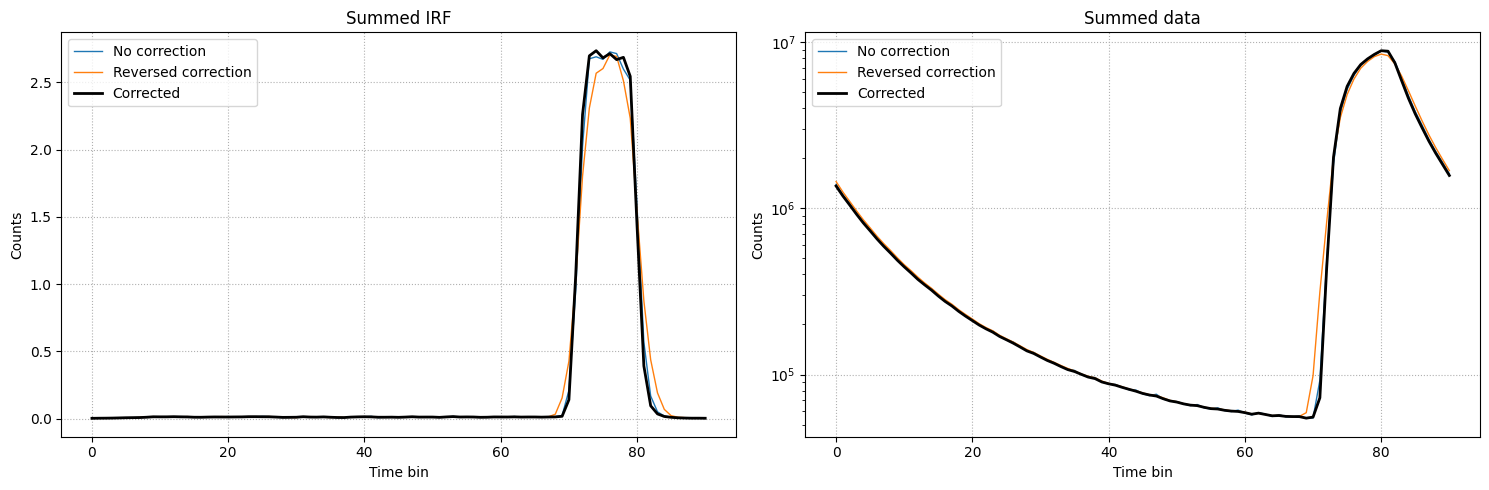

In [5]:
graph.plot_channel_skew_correction(
    irf_no_alignment=irf_summed_no_alignment,
    irf_aligned=irf_summed,
    irf_reversed=irf_summed_rev,
    data_no_alignment=data_summed_no_alignment,
    data_aligned=data_summed.sum(axis=(0, 1)),
    data_reversed=data_summed_rev.sum(axis=(0, 1)),
)


## Correct Phasors And Build Lifetime Maps


In [6]:
intensity_map = data_summed.sum(axis=-1)

if 'complex' == "phase_only":
    irf_correction = irf_phasor / abs(irf_phasor)
else:
    irf_correction = irf_phasor

phasor_map = h5_dataset_phasor_pix / irf_correction
tau_m_map = flim.calculate_tau_m(phasor_map, dfd_freq=laser_freq_mhz * 1e6) * 1e9
tau_phi_map = flim.calculate_tau_phi(phasor_map, dfd_freq=laser_freq_mhz * 1e6) * 1e9
lifetime_map = tau_m_map

threshold = 0.05
thresholded_phasor_map = flim.threshold_phasor(intensity_map, phasor_map, threshold)
thresholded_intensity_map = flim.threshold_intensity(intensity_map, threshold)
thresholded_tau_map, _, lifetime_mask = graph.threshold_lifetime_map(
    lifetime_map,
    intensity=intensity_map,
    threshold=threshold,
)

print("IRF phasor:", irf_phasor)
print("thresholded pixels:", thresholded_tau_map.size)


IRF phasor: (0.46041845417757643-0.8214422002947961j)
thresholded pixels: 110037


/home/mdonato/myDev/BrightEyes-Flim-GIT/src/brighteyes_flim/tools_phasor.py:603: RuntimeWarning: invalid value encountered in sqrt
  tau_m = np.sqrt((1. / (m ** 2)) - 1) / (2 * np.pi * dfd_freq)


Text(0.5, 1.0, 'Corrected phasor distribution')

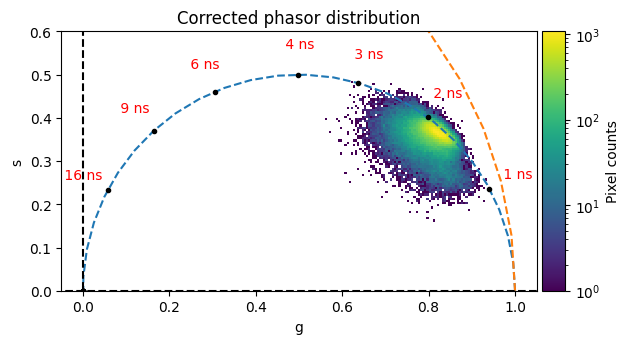

In [7]:
fig, ax = flim.plot_phasor(
    thresholded_phasor_map,
    quadrant="first",
    bins_2dplot=400,
    cmap="viridis",
    dfd_freq=laser_freq_mhz * 1e6,
)
ax.set_title("Corrected phasor distribution")


## Lifetime Visualization


/home/mdonato/.local/share/mamba/envs/venv-3.10/lib/python3.10/site-packages/brighteyes_ism/analysis/Graph_lib.py:687: RuntimeWarning: invalid value encountered in cast
  idx = (np.floor((variable - self.var_bounds[0]) / (self.var_bounds[1] - self.var_bounds[0]) * N)).astype(int)
/home/mdonato/.local/share/mamba/envs/venv-3.10/lib/python3.10/site-packages/brighteyes_ism/analysis/Graph_lib.py:807: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/mdonato/myDev/BrightEyes-Flim-GIT/src/brighteyes_flim/graph_tools.py:423: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 1300x600 with 3 Axes>,
 (<Axes: title={'center': 'Lifetime map'}>,
  <Axes: title={'center': 'Thresholded lifetime histogram'}, xlabel='Lifetime (ns)', ylabel='Pixel counts'>))

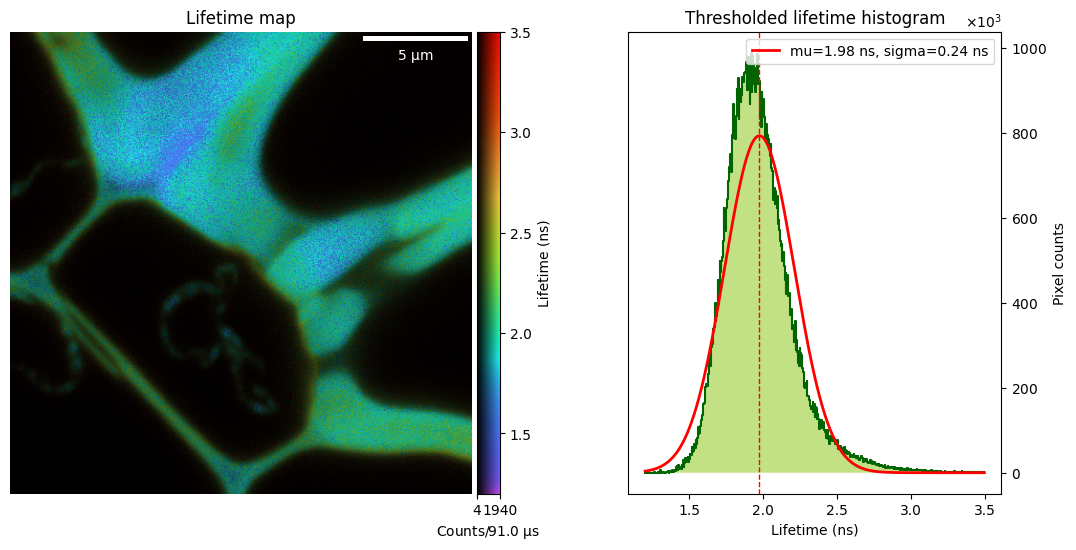

In [8]:
graph.plot_lifetime_summary(
    intensity=intensity_map,
    lifetime=lifetime_map,
    pxsize=pixel_size_x_um,
    pxdwelltime=pxdwelltime,
    lifetime_bounds=[1.2, 3.5],
    crop=30,
    threshold=threshold,
    bins=500,
    colormap="turbo",
    weighted_histogram=True,
)


/home/mdonato/myDev/BrightEyes-Flim-GIT/src/brighteyes_flim/tools_phasor.py:1098: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/mdonato/myDev/BrightEyes-Flim-GIT/src/brighteyes_flim/graph_tools.py:503: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 900x1800 with 5 Axes>,
 (<Axes: title={'center': 'Linear hue axis'}>,
  <Axes: title={'center': 'Equalized hue axis (strength=4.0, bins=4096)'}>,
  <Axes: title={'center': 'Thresholded lifetime histogram'}, xlabel='Lifetime (ns)', ylabel='Pixel counts'>))

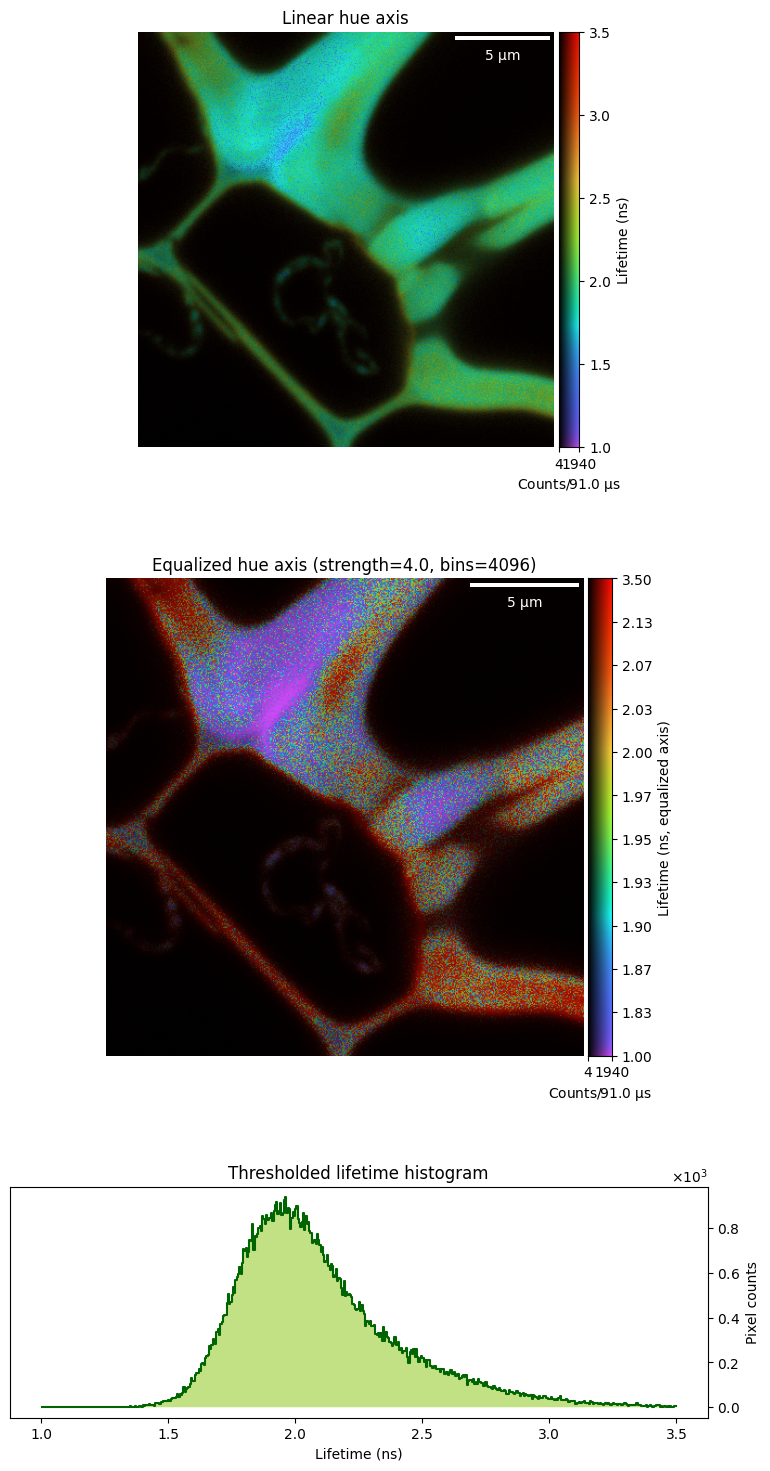

In [9]:
graph.plot_equalized_lifetime_summary(
    intensity=intensity_map,
    lifetime=lifetime_map,
    pxsize=pixel_size_x_um,
    pxdwelltime=pxdwelltime,
    lifetime_bounds=[1.0, 3.5],
    crop=30,
    threshold=threshold,
    bins=500,
    colormap="turbo",
    equalization_reference=thresholded_tau_map,
    equalization_strength=4.0,
    equalization_bins=4096,
    colorbar_ticks=12,
)


In [10]:
#show_h5_structure_html(FILE_WITH_CALIBRATION)
